In [14]:
from astropy.io import fits
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Files were obtained via NASA HEASARC mirror. The data files are compressed FITS files and will therefore be read with Astropy.

In [15]:
hdul = fits.open('../data/P0953011701PNU002SRSPEC0001.FTZ')
hdul.info()

Filename: ../data/P0953011701PNU002SRSPEC0001.FTZ
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     135   ()      
  1  SPECTRUM      1 BinTableHDU     80   4096R x 4C   [I, J, I, I]   
  2  REGION        1 BinTableHDU     23   1R x 4C   [16A, E, E, E]   
  3  GTI00005      1 BinTableHDU     22   12R x 2C   [D, D]   


The code below and its output proves that the data I am using for my project is from XMM-Newton's EPIC-pn instrument. 
It also helps me become more familiar with the structure of data.

In [16]:
hdr = hdul[0].header
print(hdr["TELESCOP"], hdr["INSTRUME"], hdr["DATE-OBS"])

hdr = hdul[1].header
print(hdr["HDUCLASS"], hdr["HDUCLAS1"], hdr["HDUCLAS2"], hdr["POISSERR"])

data = hdul["SPECTRUM"].data
print(data.columns)

XMM EPN 2024-09-22T10:23:34
OGIP SPECTRUM TOTAL True
ColDefs(
    name = 'CHANNEL'; format = 'I'
    name = 'COUNTS'; format = 'J'; unit = 'count'
    name = 'GROUPING'; format = 'I'
    name = 'QUALITY'; format = 'I'
)


In [17]:
spec_hdr = hdul["SPECTRUM"].header
spec_hdr["TLMIN1"], spec_hdr["TLMAX1"]

(0, 4095)

Below is a plot of supposedly the raw spectrum data.

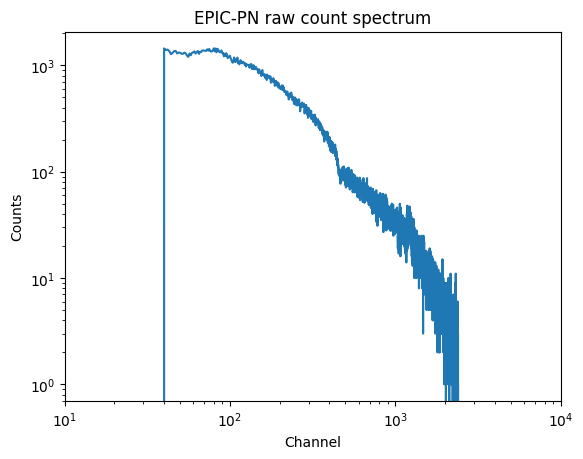

In [18]:
channels = data["CHANNEL"]
counts = data["COUNTS"]

plt.plot(channels, counts)
plt.yscale('log')
plt.xscale('log')
plt.xlim(10,10000)
plt.xlabel('Channel')
plt.ylabel('Counts')
plt.title('EPIC-PN raw count spectrum')
plt.show()

There is an unnatural jump at the beginning of the spectrum. This is most likely due to the energy range of the detector. As for the decline towards the end of the spectrum, this is most likely due to the properties of the AGN itself. There seems to be a smooth curve down, indicating a continuum source, which is to be expected from Mrk279. One could also expect a form of power-law emission which does seem to be present with a break at a channel value of around 30. Furthermore, the end of the spectrum also demonstrates the Poisson error on the data quite well. As higher energy counts become scarcer, the statistical uncertainty becomes much more visible. This could also be because of the effective area of the detector decreasing.

to avoid memory leaks, close the data file

In [19]:
hdul.close()